In [3]:
import missingno as msno
import matplotlib.pyplot as plt
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

# Работа с объединенным датасетом

In [4]:
df = pd.read_csv("merged_dataset.csv")
missing_percentages = (df.isnull().sum() / len(df)) * 100
print("\nПроцент пропусков в столбцах:")
print(missing_percentages.sort_values(ascending=False))


Процент пропусков в столбцах:
salary_to          85.708155
salary_from        60.772532
experience          1.502146
id                  0.000000
area_name           0.000000
name                0.000000
published_at        0.000000
salary_currency     0.000000
employer_name       0.000000
alternate_url       0.000000
schedule            0.000000
employment          0.000000
dtype: float64


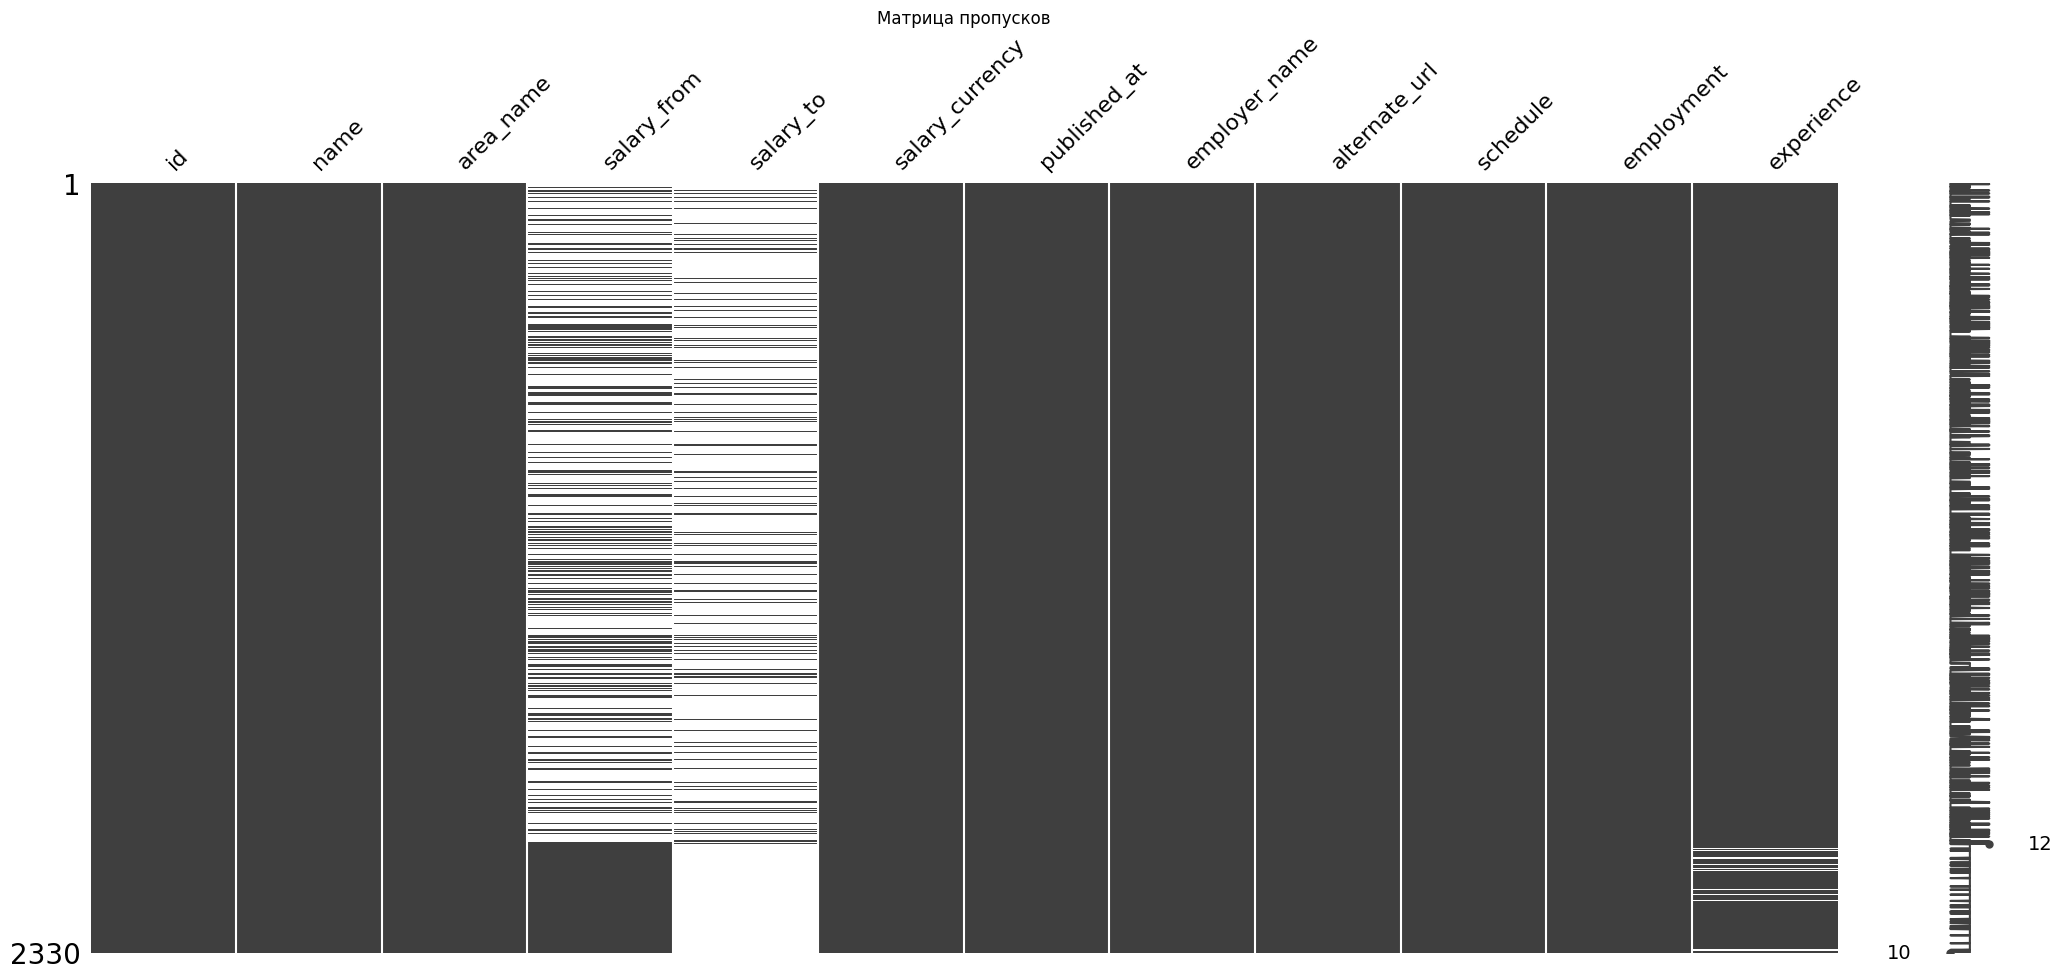

In [5]:
msno.matrix(df)
plt.title('Матрица пропусков')
plt.show()

## Наибольший процент пропусков в столбцах salary_from (60,7%) и salary_to (86%)

Пропуски в зарплатных данных не случайны - часто работодатели не указывают зарплатный диапазон

In [6]:
#Заполним данные salary_to значениями из salary_from где это возможно
import pandas as pd
import numpy as np

df = pd.read_csv("merged_dataset.csv")
condition = (df['salary_from'].notna()) & (df['salary_to'].isna())

df.loc[condition, 'salary_to'] = df.loc[condition, 'salary_from']

print("Результаты заполнения:")
print(f"Было пропусков в salary_to: {df['salary_to'].isna().sum()}")
print(f"Осталось пропусков в salary_to: {df['salary_to'].isna().sum()}")

df['salary_data_quality'] = np.where(
    df['salary_from'].notna() & df['salary_to'].notna(), 'full',
    np.where(df['salary_from'].notna(), 'only_from', 'estimated')
)

print("\nКачество зарплатных данных:")
print(df['salary_data_quality'].value_counts(normalize=True) * 100)

Результаты заполнения:
Было пропусков в salary_to: 1336
Осталось пропусков в salary_to: 1336

Качество зарплатных данных:
salary_data_quality
estimated    60.772532
full         39.227468
Name: proportion, dtype: float64


# Исправление пропусков


## Метод 1. Удаление строк с пропущенными значениями
Этот метод подразумевает, что вы полностью исключаете из анализа те строки, в которых отсутствует информация по ключевым столбцам (например, salary_from и salary_to). Это самый простой и быстрый способ — он снижает сложность обработки данных, так как не требуется дополнительная логика по заполнению отсутствующих значений.

Преимущества:
- Простота реализации.
- Нет риска введения дополнительных ошибок, связанных с оценками или прогнозами для отсутствующих данных.

Недостатки:
- Потенциально можно потерять значительный объём данных (в вашем случае процент пропусков для salary_to составляет около 86%, а для salary_from — около 61%), что может снизить представительность выборки и исказить результаты анализа.

In [7]:
# Предположим, что нас интересует только работа с информацией о зарплате
df_clean_1 = df.dropna(subset=['salary_from', 'salary_to'])
print("Размер датасета после удаления строк с пропусками:", df_clean_1.shape)


Размер датасета после удаления строк с пропусками: (914, 13)


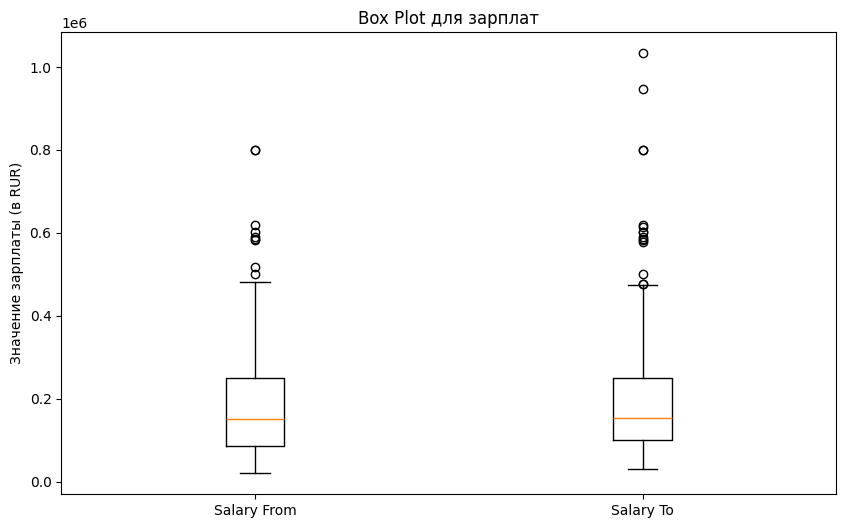

In [8]:
import matplotlib.pyplot as plt

# Построение box plot для столбцов 'salary_from' и 'salary_to'
plt.figure(figsize=(10, 6))
plt.boxplot([df_clean_1['salary_from'].dropna(), df_clean_1['salary_to'].dropna()],
            labels=['Salary From', 'Salary To'])
plt.title("Box Plot для зарплат")
plt.ylabel("Значение зарплаты (в RUR)")
plt.show()


In [9]:
# Вывод описательной статистики для 'salary_from' и 'salary_to'
salary_stats = df_clean_1[['salary_from', 'salary_to']].describe()
print("Статистика по зарплатам:\n")
print(salary_stats)

Статистика по зарплатам:

         salary_from     salary_to
count     914.000000  9.140000e+02
mean   178907.070941  1.906969e+05
std    114809.889500  1.200372e+05
min     20000.000000  3.000000e+04
25%     85250.000000  1.000000e+05
50%    150000.000000  1.537500e+05
75%    250000.000000  2.500000e+05
max    800000.000000  1.033108e+06


##  Метод 2. Продвинутая импутация с использованием моделей
Использовать методы импутации, чтобы заполнить отсутствующие значения прогнозируемыми на основе имеющихся данных. 

Преимущества:
- Сохранение максимального объёма данных для анализа.
- Учет дополнительной информации в датасете для получения более точных оценок, что может улучшить качество последующего анализа или предсказания.

Недостатки:
- Более высокая вычислительная сложность и необходимость подбора параметров модели.
- Риск введения ошибок, если модель неправильно обучена или если имеются сильные выбросы в данных.

In [10]:
from sklearn.impute import KNNImputer
import pandas as pd

# Кодирование experience
exp_map = {
    'Нет опыта': 0,
    'От 1 года до 3 лет': 1,
    'От 3 до 6 лет': 2,
    'Более 6 лет': 3
}
df['experience_encoded'] = df['experience'].map(exp_map)

# One-Hot Encoding для schedule
schedule_dummies = pd.get_dummies(df['schedule'], prefix='schedule')
df = pd.concat([df, schedule_dummies], axis=1)

# Только числовые колонки для импутации
columns_for_imputation = ['salary_from', 'salary_to', 'experience_encoded']
df_impute = df[columns_for_imputation]

# Инициализируем KNN импутатор
imputer = KNNImputer(n_neighbors=10)
df_imputed = imputer.fit_transform(df_impute)

# Обновляем значения в датафрейме
df[columns_for_imputation] = df_imputed

inv_exp_map = {v: k for k, v in exp_map.items()}
df['experience'] = df['experience_encoded'].round().astype(int).map(inv_exp_map)

print("Импутация завершена. Пример заполненных данных:")
print(df[columns_for_imputation + ['experience']].head())


Импутация завершена. Пример заполненных данных:
   salary_from  salary_to  experience_encoded          experience
0    118841.44  152687.44                 1.0  От 1 года до 3 лет
1    118841.44  152687.44                 1.0  От 1 года до 3 лет
2    189500.00  243483.07                 2.0       От 3 до 6 лет
3    150000.00  150000.00                 0.0           Нет опыта
4    189500.00  243483.07                 2.0       От 3 до 6 лет


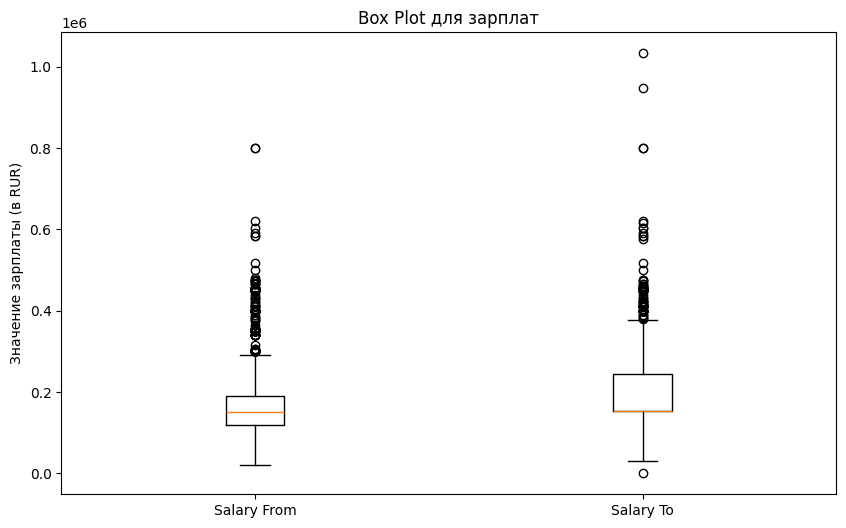

In [11]:
import matplotlib.pyplot as plt

# Построение box plot для столбцов 'salary_from' и 'salary_to'
plt.figure(figsize=(10, 6))
plt.boxplot([df['salary_from'].dropna(), df['salary_to'].dropna()],
            labels=['Salary From', 'Salary To'])
plt.title("Box Plot для зарплат")
plt.ylabel("Значение зарплаты (в RUR)")
plt.show()


In [12]:
# Вывод описательной статистики для
salary_stats = df[['salary_from', 'salary_to']].describe()
print("Статистика по зарплатам:\n")
print(salary_stats)

Статистика по зарплатам:

         salary_from     salary_to
count    2330.000000  2.330000e+03
mean   166252.330004  1.966209e+05
std     83112.534031  9.239992e+04
min     20000.000000  3.500000e+02
25%    118841.440000  1.526874e+05
50%    150000.000000  1.526874e+05
75%    189500.000000  2.434831e+05
max    800000.000000  1.033108e+06


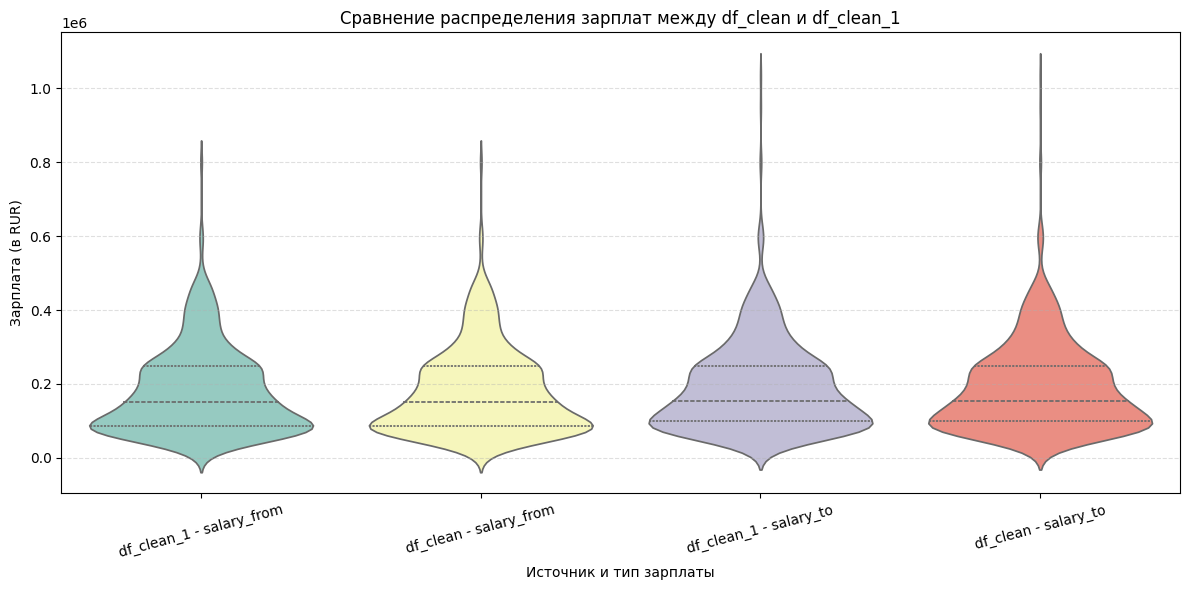

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Добавим столбец с названием источника данных
df1 = df_clean_1[['salary_from', 'salary_to']].dropna().copy()
df1['source'] = 'df_clean_1'

df2 = df_clean_1[['salary_from', 'salary_to']].dropna().copy()
df2['source'] = 'df_clean'

# Объединяем оба датафрейма
combined = pd.concat([df1, df2], ignore_index=True)

# Преобразуем в "длинный" формат для seaborn
melted = pd.melt(combined, id_vars='source',
                 value_vars=['salary_from', 'salary_to'],
                 var_name='Salary Type', value_name='Salary')

melted['Group'] = melted['source'] + ' - ' + melted['Salary Type']

# Построение violinplot
plt.figure(figsize=(12, 6))
sns.violinplot(x='Group', y='Salary', data=melted, inner='quartile', palette='Set3')
plt.title('Сравнение распределения зарплат между df_clean и df_clean_1')
plt.ylabel('Зарплата (в RUR)')
plt.xlabel('Источник и тип зарплаты')
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## Таким образом, мы сохраняем размер выборки благодаря использованию KNN без потери распределения данных

In [14]:
# Удаляем вспомогательные столбцы
columns_to_drop = [
    'salary_data_quality',
    'experience_encoded',
    'schedule_Гибкий график',
    'schedule_Полный день',
    'schedule_Сменный график',
    'schedule_Удаленная работа'
]

df_final = df.drop(columns=columns_to_drop)

# Работа с категориальными переменными

## Базовый вариант

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

df_processed = df_final.copy()

df_processed['salary_from'] = pd.to_numeric(df_processed['salary_from'], errors='coerce')
df_processed['salary_to'] = pd.to_numeric(df_processed['salary_to'], errors='coerce')

df_processed.dropna(subset=['salary_from', 'salary_to'], inplace=True)

df_processed['salary_mean'] = (df_processed['salary_from'] + df_processed['salary_to']) / 2

# One-Hot Encoding для столбцов с небольшим количеством уникальных значений
df_processed = pd.get_dummies(df_processed, columns=['salary_currency', 'schedule', 'employment'], prefix=['currency', 'schedule', 'employment'])

# Label Encoding для столбца 'experience'
experience_mapping = {'Нет опыта': 0, 'От 1 года до 3 лет': 1, 'От 3 до 6 лет': 2}
df_processed['experience_encoded'] = df_processed['experience'].map(experience_mapping).fillna(-1) # Заполняем NaN, если есть необработанные значения

# Частотное кодирование для столбцов с большим количеством уникальных значений
def frequency_encode_new(df_proc, column):
    freq = df_proc[column].value_counts(normalize=True)
    df_proc[column + '_freq'] = df_proc[column].map(freq)
    return df_proc

df_processed = frequency_encode_new(df_processed, 'name')
df_processed = frequency_encode_new(df_processed, 'area_name')
df_processed = frequency_encode_new(df_processed, 'employer_name')

# Удаление столбца с уникальными значениями
if 'alternate_url' in df_processed.columns:
    df_processed = df_processed.drop('alternate_url', axis=1)

# Удаление столбца 'published_at'
if 'published_at' in df_processed.columns:
    df_processed = df_processed.drop('published_at', axis=1)

# Удаление столбцов 'salary_from' и 'salary_to'
df_processed = df_processed.drop(columns=['salary_from', 'salary_to'], axis=1)

# Удаление исходных категориальных столбцов после кодирования
columns_to_drop = ['name', 'area_name', 'employer_name', 'experience']
df_processed = df_processed.drop(columns=[col for col in columns_to_drop if col in df_processed.columns], axis=1)


In [16]:
df_processed.head()

,id,salary_mean,currency_RUR,schedule_Гибкий график,schedule_Полный день,schedule_Сменный график,schedule_Удаленная работа,employment_Полная занятость,employment_Проектная работа,employment_Стажировка,employment_Частичная занятость,experience_encoded,name_freq,area_name_freq,employer_name_freq
0,118751151,135764.440,True,False,True,False,False,True,False,False,False,1.0,0.000429,0.026609,0.000429
1,118782864,135764.440,True,False,True,False,False,True,False,False,False,1.0,0.008155,0.634764,0.008584
2,119447859,216491.535,True,False,True,False,False,True,False,False,False,2.0,0.000429,0.634764,0.008155
3,118524897,150000.000,True,False,True,False,False,True,False,False,False,0.0,0.000429,0.634764,0.000429
4,118276459,216491.535,True,False,True,False,False,True,False,False,False,2.0,0.000429,0.634764,0.003004


In [17]:
if 'salary_mean' in df_processed.columns:
    y_new = df_processed['salary_mean']
    X_new = df_processed.drop('salary_mean', axis=1)
else:
    print("Столбец 'salary_mean' не найден в df_processed.")
    exit()

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

model_new = LinearRegression()
model_new.fit(X_train_new, y_train_new)

y_pred_new = model_new.predict(X_test_new)

mse_new = mean_squared_error(y_test_new, y_pred_new)
rmse_new = np.sqrt(mse_new)
r_squared_new = r2_score(y_test_new, y_pred_new)

print("Обучена новая модель линейной регрессии (model_new).")
print("\nОценка новой модели:")
print(f"Среднеквадратическая ошибка (MSE): {mse_new:.2f}")
print(f"Корень из среднеквадратической ошибки (RMSE): {rmse_new:.2f}")
print(f"Коэффициент детерминации (R^2): {r_squared_new:.2f}")

Обучена новая модель линейной регрессии (model_new).

Оценка новой модели:
Среднеквадратическая ошибка (MSE): 4586240344.53
Корень из среднеквадратической ошибки (RMSE): 67721.79
Коэффициент детерминации (R^2): 0.35


## Продвинутый вариант

In [18]:
import pandas as pd
from sklearn.model_selection import KFold

# Исходные данные
raw_data = df_final.copy()

# Этап очистки и преобразования
cleaned_data = raw_data.copy()

# Обработка зарплатных полей
cleaned_data['salary_from'] = pd.to_numeric(cleaned_data['salary_from'], errors='coerce')
cleaned_data['salary_to'] = pd.to_numeric(cleaned_data['salary_to'], errors='coerce')
cleaned_data.dropna(subset=['salary_from', 'salary_to'], inplace=True)

# Создаем salary_mean вместо target_salary
cleaned_data['salary_mean'] = (cleaned_data['salary_from'] + cleaned_data['salary_to']) / 2

# One-Hot Encoding для категорий с малым числом уникальных значений
categorical_features = ['salary_currency', 'schedule', 'employment']
cleaned_data = pd.get_dummies(cleaned_data, columns=categorical_features, 
                             prefix=['curr', 'sched', 'employ'])

# Label Encoding для опыта работы
experience_mapping = {'Нет опыта': 0, 'От 1 года до 3 лет': 1, 'От 3 до 6 лет': 2}
cleaned_data['experience_level'] = cleaned_data['experience'].map(experience_mapping).fillna(-1)

# === Продвинутая обработка категориальных признаков ===

def create_target_encoding(series, target_series):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    encoded = pd.Series(np.zeros(len(series)), index=series.index)
    global_mean = target_series.mean()

    for train_idx, val_idx in kf.split(series):
        train_series = series.iloc[train_idx]
        train_target = target_series.iloc[train_idx]
        group_means = train_target.groupby(train_series).mean()
        encoded.iloc[val_idx] = series.iloc[val_idx].map(group_means).fillna(global_mean)
    
    return encoded.fillna(global_mean)

cleaned_data['job_title_encoded'] = create_target_encoding(cleaned_data['name'], cleaned_data['salary_mean'])
cleaned_data['region_encoded'] = create_target_encoding(cleaned_data['area_name'], cleaned_data['salary_mean'])

# Smoothed Frequency Encoding для работодателей
def create_smoothed_encoding(series, target_series, weight=10):
    global_mean = target_series.mean()
    group_means = target_series.groupby(series).mean()
    group_counts = series.value_counts()
    smoothed = (group_counts * group_means + weight * global_mean) / (group_counts + weight)
    return series.map(smoothed).fillna(global_mean)

cleaned_data['employer_encoded'] = create_smoothed_encoding(
    cleaned_data['employer_name'], 
    cleaned_data['salary_mean']
)

# === Формирование финального набора признаков ===
features_df = cleaned_data.drop(columns=[
    'name', 'area_name', 'employer_name', 'experience',
    'alternate_url', 'published_at', 'salary_from', 'salary_to',  # Удаляем исходные столбцы
], errors='ignore')


Финальные признаки: ['id', 'salary_mean', 'curr_RUR', 'sched_Гибкий график', 'sched_Полный день', 'sched_Сменный график', 'sched_Удаленная работа', 'employ_Полная занятость', 'employ_Проектная работа', 'employ_Стажировка', 'employ_Частичная занятость', 'experience_level', 'job_title_encoded', 'region_encoded', 'employer_encoded']


In [19]:
features_df.head()

,id,salary_mean,curr_RUR,sched_Гибкий график,sched_Полный день,sched_Сменный график,sched_Удаленная работа,employ_Полная занятость,employ_Проектная работа,employ_Стажировка,employ_Частичная занятость,experience_level,job_title_encoded,region_encoded,employer_encoded
0,118751151,135764.440,True,False,True,False,False,True,False,False,False,1.0,181436.635575,141106.477234,177284.617796
1,118782864,135764.440,True,False,True,False,False,True,False,False,False,1.0,202801.828571,193313.358105,169824.827358
2,119447859,216491.535,True,False,True,False,False,True,False,False,False,2.0,181436.635575,192959.201568,184107.237267
3,118524897,150000.000,True,False,True,False,False,True,False,False,False,0.0,181436.635575,189791.384296,178578.759614
4,118276459,216491.535,True,False,True,False,False,True,False,False,False,2.0,181436.635575,193313.358105,182656.968868


In [20]:
if 'salary_mean' in features_df.columns:
    y_new = features_df['salary_mean']
    X_new = features_df.drop('salary_mean', axis=1)
else:
    print("Столбец 'salary_mean' не найден в features_df.")
    exit()

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

model_new = LinearRegression()
model_new.fit(X_train_new, y_train_new)

y_pred_new = model_new.predict(X_test_new)

mse_new = mean_squared_error(y_test_new, y_pred_new)
rmse_new = np.sqrt(mse_new)
r_squared_new = r2_score(y_test_new, y_pred_new)

print("Обучена новая модель линейной регрессии (model_new).")
print("\nОценка новой модели:")
print(f"Среднеквадратическая ошибка (MSE): {mse_new:.2f}")
print(f"Корень из среднеквадратической ошибки (RMSE): {rmse_new:.2f}")
print(f"Коэффициент детерминации (R^2): {r_squared_new:.2f}")

Обучена новая модель линейной регрессии (model_new).

Оценка новой модели:
Среднеквадратическая ошибка (MSE): 3504326390.17
Корень из среднеквадратической ошибки (RMSE): 59197.35
Коэффициент детерминации (R^2): 0.51


# Финальный датасет

In [21]:
features_df.head()

,id,salary_mean,curr_RUR,sched_Гибкий график,sched_Полный день,sched_Сменный график,sched_Удаленная работа,employ_Полная занятость,employ_Проектная работа,employ_Стажировка,employ_Частичная занятость,experience_level,job_title_encoded,region_encoded,employer_encoded
0,118751151,135764.440,True,False,True,False,False,True,False,False,False,1.0,181436.635575,141106.477234,177284.617796
1,118782864,135764.440,True,False,True,False,False,True,False,False,False,1.0,202801.828571,193313.358105,169824.827358
2,119447859,216491.535,True,False,True,False,False,True,False,False,False,2.0,181436.635575,192959.201568,184107.237267
3,118524897,150000.000,True,False,True,False,False,True,False,False,False,0.0,181436.635575,189791.384296,178578.759614
4,118276459,216491.535,True,False,True,False,False,True,False,False,False,2.0,181436.635575,193313.358105,182656.968868


In [22]:
features_df.to_csv("final_dataset.csv")